In [2]:
# !pip install lightkurve
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

C:\Users\dwzlo\anaconda3\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
search_result = lk.search_lightcurve("Kepler-9", mission="Kepler")

indices = list(range(0, 3)) + list(range(6, 10)) + [23, 22, 21, 39, 37, 36, 38, 47, 46, 48]; # we want long exposure time
lim_search_result = search_result[indices]
search_result



#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr003323887,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr003323887,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr003323887,0.0
3,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
4,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
5,Kepler Quarter 07,2010,Kepler,60,kplr003323887,0.0
6,Kepler Quarter 04,2010,Kepler,1800,kplr003323887,0.0
7,Kepler Quarter 05,2010,Kepler,1800,kplr003323887,0.0
8,Kepler Quarter 06,2010,Kepler,1800,kplr003323887,0.0


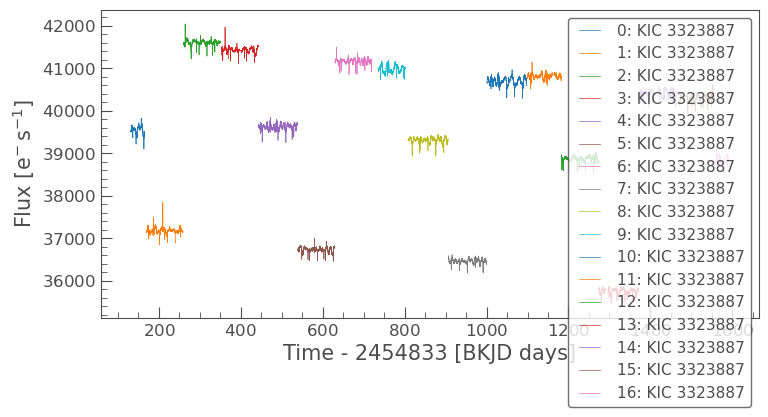

In [6]:
lc_collection = lim_search_result.download_all()
lc_collection.plot();
plt.show()

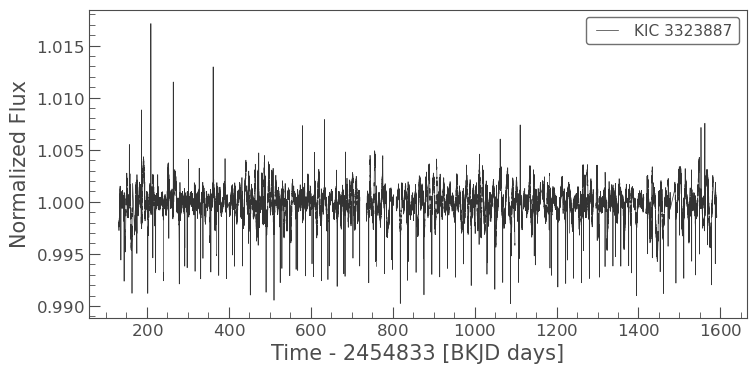

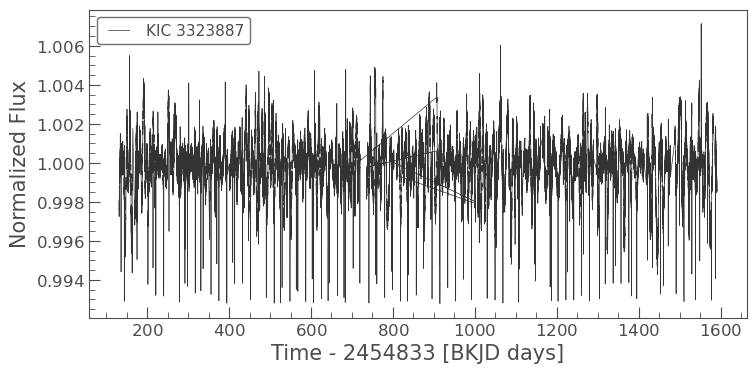

In [7]:
# stitch and flatten
lc = lc_collection.stitch().flatten(window_length=901) 
lc.plot();
plt.show()

lc = lc_collection.stitch().flatten(window_length=901).remove_outliers()
lc.plot();
plt.show()

#with 'outliers' makes the scale larger for the clarity of graph, and i think all the dips are legitimate, so I don't mind keeping outliers.
lc = lc_collection.stitch().flatten(window_length=901) 

In [8]:
for i in range(30000, 65000, 1000):
    print(i, lc.time[i].value);

30000 971.3966413031012
31000 992.0135692177937
32000 820.9197243178423
33000 841.5381936156482
34000 862.8105942712427
35000 884.0624647135337
36000 905.5593448977743
37000 755.6123159177514
38000 778.9068396157745
39000 799.6475133355561
40000 1019.209540119693
41000 1040.827236510595
42000 1061.4437415942302
43000 1085.513517653424
44000 1107.4381880927758
45000 1131.9583356248258
46000 1152.5556636741312
47000 1178.670593035844
48000 1200.208497238309
49000 1221.6852412815933
50000 1242.4263227163465
51000 1263.9642151683947
52000 1286.3600696055946
53000 1313.6188309692443
54000 1334.1953461788944
55000 1355.6910288363288
56000 1378.4532134535984
57000 1399.1515068441731
58000 1424.8761283628846
59000 1446.3304397248576
60000 1466.9267935222815
61000 1500.0695942983511
62000 1520.7485833193932
63000 1542.572233436811
64000 1564.580057421801


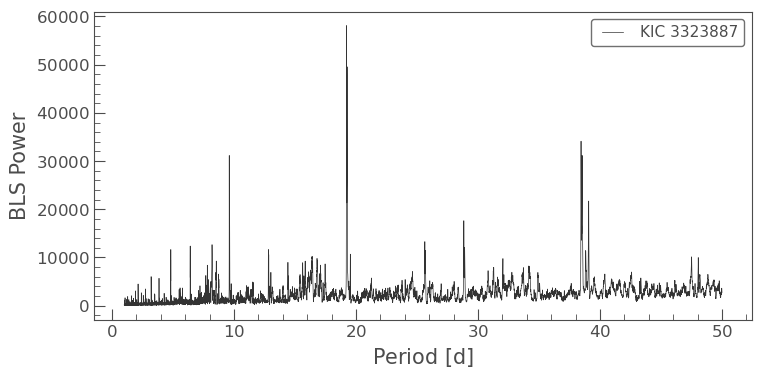

planet_b_period: 19.22002200220022 d
planet_b_t0: 145.99801296925523
planet_b_dur: 0.15 d


In [9]:
# From lightkurve documentation

# Create array of periods to search
period = np.linspace(1, 50, 10000)
# Create a BLSPeriodogram
bls = lc.to_periodogram(method='bls', period=period, frequency_factor=500);
bls.plot();
plt.show()

planet_b_period = bls.period_at_max_power
planet_b_t0 = bls.transit_time_at_max_power
planet_b_dur = bls.duration_at_max_power
print(f"planet_b_period: {planet_b_period}");
print(f"planet_b_t0: {planet_b_t0}");
print(f"planet_b_dur: {planet_b_dur}");


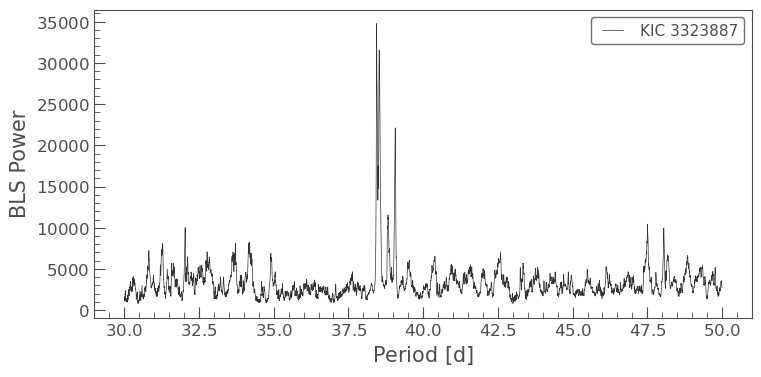

planet_c_period: 38.444844484448446 d
planet_c_t0: 165.07301296925522
planet_c_dur: 0.15 d


In [10]:
# Now, still following lightkurve tutorial, I want to mask, identify planet Kepler 9-c (P ~ 39 days), mask,
# then get rid of Kepler 9-c's mask from the light curve.
period = np.linspace(30, 50, 10000)
bls = lc.to_periodogram(method='bls', period=period, frequency_factor=500); # box least squares periodogram
bls.plot();
plt.show()

planet_c_period = bls.period_at_max_power
planet_c_t0 = bls.transit_time_at_max_power
planet_c_dur = bls.duration_at_max_power
print(f"planet_c_period: {planet_c_period}");
print(f"planet_c_t0: {planet_c_t0}");
print(f"planet_c_dur: {planet_c_dur}");

#planet_c_mask = bls.get_transit_mask(period=planet_c_period,
                                     #transit_time=planet_c_t0,
                                     #duration=planet_c_dur)
#lc[planet_c_mask] = 0
#period = np.linspace(1, 30, 5000)
#bls = masked_lc.to_periodogram('bls', period=period, frequency_factor=500)
#bls.plot();

t_start: 131.51301296925521
length: 65031
t_end: 1591.0019382779064
num_days: 1459.4889253086512
t_increment: 0.022442972202621078
t_transit_the[0]: 144.23345025
76
76


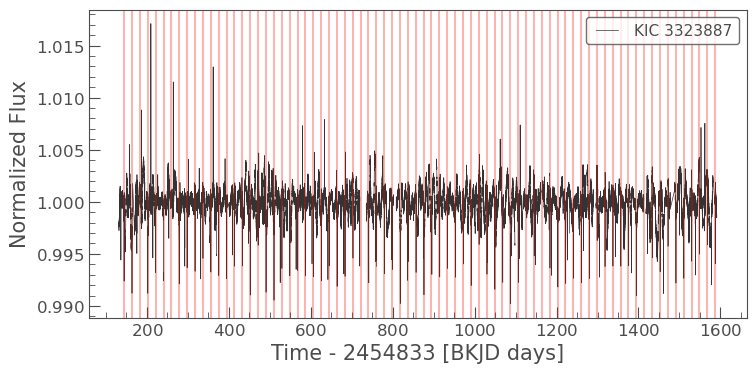

In [11]:
#theoretical
t_start = lc.time[0].value # 131.51
length = np.size(lc.time) # 26954
t_end = lc.time[length - 1].value #719.55
num_days = t_end - t_start; # 588.03
t_increment = num_days/length
print(f"t_start: {t_start}");
print(f"length: {length}");
print(f"t_end: {t_end}");
print(f"num_days: {num_days}");
print(f"t_increment: {t_increment}");

kepler_9b_period = 19.2242 # days, as per Open Exoplanet Archive (updated 2015); https://www.openexoplanetcatalogue.com/planet/Kepler-9%20b/
kepler_9b_period = 19.24 # days, as per NASA Exoplanet Archive (updated 2010); https://exoplanetarchive.ipac.caltech.edu/overview/K00377.01
# 19.24 fits data better to find peaks. Since we will subtract off a linear long-term trend, it is fine to use this for now.

num_transits = int(np.round(num_days / kepler_9b_period));
n_transit_the = np.arange(0, num_transits, 1); #
t_peak0 = 144.23345025; # found below and retroactively fixed
t_transit_the = t_peak0 + n_transit_the * kepler_9b_period
print(f"t_transit_the[0]: {t_transit_the[0]}");

print(np.size(n_transit_the))
print(np.size(t_transit_the))

lc.plot()
for n in range(np.size(t_transit_the)):
    plt.axvline(t_transit_the[n], color='red', alpha=0.3) # vertical line check
plt.show()

# Generative AI helped with the idea of plotting a vertical line for each peak.

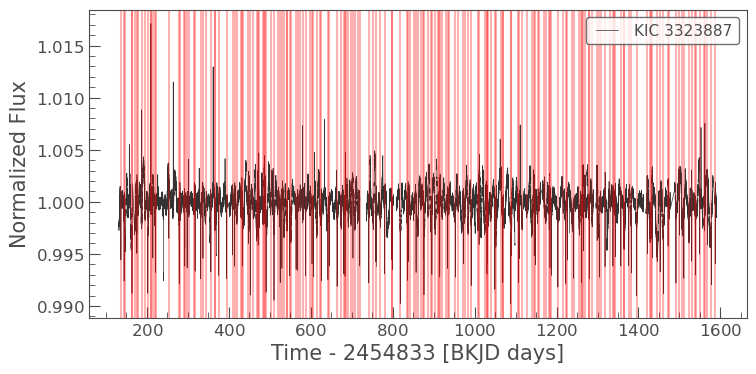

In [12]:
# Now we find the actual observed peaks and compare them with the peaks from calculations. 
# From literature, we expect 5-minute variations max, which is 0.003 days
# This worries me slightly because each data point is roughly 0.02 days apart (num_days / length)

from scipy.signal import find_peaks

flux_inverted = -lc.flux.value
peaks, props = find_peaks(flux_inverted, prominence = 0.002, distance = 30)
t_obs = lc.time.value[peaks]

lc.plot()
for n in range(np.size(t_obs)):
    plt.axvline(t_obs[n], color='red', alpha=0.3)
plt.show()

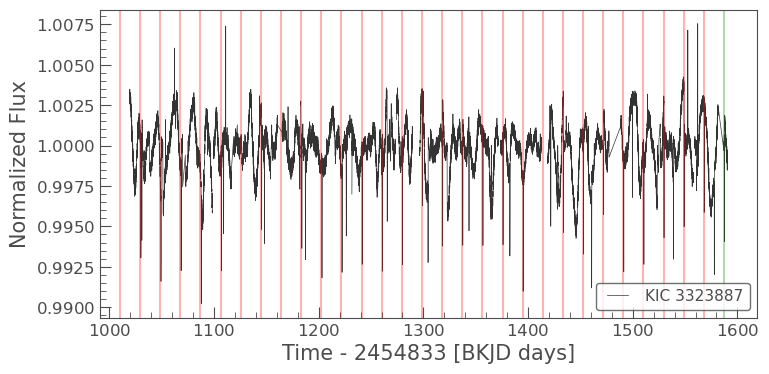

idx_transit_the, 64848

1.000102857327639
1.0001910974596449
1.0005561097163125
1.0001881143584952
1.00037044150076
1.000385953626738
1.0005083204358955
1.0000461784057961
1.0005553937720366
1.0006642769639977
1.0005902363934642
1.0003850586963932
1.000676448016688
1.0004641108768582
1.0009758917100873
1.0006044956169593
1.000315910411745
1.000576514128176
1.0009522655489822
1.0005414925206793
1.0005640447653705
1.000796786317064
1.0003411474474708
1.0007439854267157
1.0007236406768751
1.0004633352705592
1.0006767463268031
1.0011050003278428
1.0011876918917104
1.0008713041837816
1.0010545262563912
1.0010612084029664
1.0007703560408783
1.0013150106487763
1.0012912651636252
1.00092291183367
1.0009559049323846
1.0014543811344865
1.0013282556178804
1.0015506756395962
1.0013527170473073
1.0018057904499118
1.0012747984452792
1.0017134336383196
1.0016371855729354
1.0016380208412572
1.0015229924609277
1.0018686742221459
1.0015911264911852
1.0018094894953375
1.0016938644947782
1.001697921512341

In [13]:
# as can be seen, find_peaks sucks. Let's find the time manually looking at data.
curr = 75                                                      ## CHANGE INDEX FOR MANUAL PEAK INSPECTION
# In the case of possible double peaks, we manually verify through printed values the peak of the correct depth
# ... as expected
# t_transit_dur (duration) is not fully legitimate as it considers peak time only when below 0.995
# ... however it is observed on either side of the peak it very quickly rises back to 0.999, so it gives a 
# ... rough idea of t_transit_obs uncertainty, if it is needed.

# Replot for clarity
lc[40000:65000].plot()
for n in range(45, np.size(t_transit_the)):
    if n == curr:
        plt.axvline(t_transit_the[n], color='green', alpha=0.3)
    else:
        plt.axvline(t_transit_the[n], color='red', alpha=0.3) # vertical line check
plt.show()

# Finds closest index based on time value. np.argmin finds position of smallest value.
transit_idx = np.argmin(np.abs(lc.time.value - t_transit_the[curr]))  ## CHANGE INDEX FOR MANUAL PEAK INSPECTION
print(f"idx_transit_the, {transit_idx}\n");
#repeat.

t_transit_start = 0;
flag_start = 0;
idx_transit_start = 0;
t_transit_end = 0;
idx_transit_end = 0;

threshold = 0.995;

for idx in range(transit_idx - 100, transit_idx + 100):
    if (lc.flux[idx] < threshold or  # during transit
        lc.flux[idx + 1] < threshold or  # right before transit
        lc.flux[idx - 1] < threshold):  # right after transit
        print(f"idx: {idx}");
        print(f"time: {lc.time[idx]}")
        print(f"flux: {lc.flux[idx]}")
        print("")
    else:
        print(lc.flux[idx]);

    # choose endpoints at base;
    if (lc.flux[idx] > threshold and lc.flux[idx + 1] < threshold and flag_start == 0): # first of any peak.
        idx_transit_start = idx;
        t_transit_start = lc.time[idx];
        flag_start = 1;

    if (lc.flux[idx] > threshold and lc.flux[idx - 1] < threshold):
        idx_transit_end = idx;
        t_transit_end = lc.time[idx]

t_transit_dur = t_transit_end - t_transit_start
t_middle = (t_transit_end.value + t_transit_start.value)/2;
idx_transit_dur = idx_transit_end - idx_transit_start
idx_middle = (idx_transit_end + idx_transit_start)/2

print("");
print(f"idx_transit_start: {idx_transit_start}");
print(f"t_transit_start: {t_transit_start}");
print(f"idx_transit_end: {idx_transit_end}");
print(f"t_transit_end: {t_transit_end}");
print(f"idx_transit_dur: {idx_transit_dur}");
print(f"t_transit_dur: {t_transit_dur}");
print(f"idx_middle: {idx_middle}");
print(f"t_middle: {t_middle}");
print("");

In [33]:
# DO NOT RUN THIS CEll; resets values
#n_transit_obs = np.arange(0, num_transits, 1); #
#idx_transit_obs = np.zeros(num_transits)
#t_transit_obs = np.zeros(num_transits)
#idx_transit_dur_obs = np.zeros(num_transits);
#t_transit_dur_obs = np.zeros(num_transits);

#idx_transit_obs = np.concatenate((idx_transit_obs, np.zeros(12))); 
#t_transit_obs = np.concatenate((t_transit_obs , np.zeros(12))); 
#idx_transit_dur_obs = np.concatenate((idx_transit_dur_obs, np.zeros(12)));
#t_transit_dur_obs = np.concatenate((t_transit_dur_obs, np.zeros(12)));

np.size(idx_transit_obs)

76

In [66]:
# Observed values
idx_transit_obs[curr] = idx_middle; 
t_transit_obs[curr] = t_middle; 
idx_transit_dur_obs[curr] = idx_transit_dur;
t_transit_dur_obs[curr] = t_transit_dur.value;

print(f"idx_transit_obs: {idx_transit_obs}");
print(f"t_transit_obs: {t_transit_obs}");
print(f"t_transit_the: {t_transit_the}");
print(f"idx_transit_dur_obs: {idx_transit_dur_obs}");
print(f"t_transit_dur_obs: {t_transit_dur_obs}");
print("");

# No peak around expected transits (starting from 0): [2, 6, 17, 30, 45, 51, 53, 60, 66 ] ... as predicted by the light curve. 
# ... Will remove from array. 
# No flux value for idx 487 (t = 240.36388) makes peak 6 hard. Assume t_transit_start at idx 487.
# peak [40, 42, 44, 46] have nasty double peaks (centre goes back to 1!). 
# ... Take peak as the numerical middle, i'm not sure how to resolve.
# peak [69, 74] visually observed peak BUT not below 0.995. Lightened condition to < 0.9975 for these peak.

# Technically, t_increment between indices is 0.0218... so the time values are only precise to 0.01 days... but we keep anyways.

# ChatGPT was used to format the printed lists below into np arrays, which is just putting commas in between values because manual is boring :( 

idx_transit_obs: [  618.5  1552.5     0.   3079.5  4010.   4874.      0.   6601.   7450.5
  8387.   9219.  10012.5 10946.  11837.  12574.  13510.5 14382.      0.
 16188.  17090.5 18025.  18895.5 19789.5 20728.  21618.5 22555.5 23448.
 24345.  25281.5 26174.  26946.  27250.  28184.  28987.5 29915.5 30550.5
 31482.  32382.5 33287.  34176.5 35050.  35995.  36882.5 37781.  38721.
     0.  40544.5 41412.  42302.  43110.  43980.      0.  45655.      0.
 47218.5 48139.  49031.  49958.  50844.  51692.      0.  53232.  54124.5
 55057.  55884.5 56815.      0.  58432.5 59320.5 60208.5 60589.  61510.5
 62387.  63316.  64181.5 64861.5]
t_transit_obs: [ 144.23345025  163.48253773    0.          201.9595293   221.19760321
  240.42518217    0.          278.92054228  298.15782481  317.43598403
  336.67340021  355.94167905  375.20003123  394.46892509  413.71770399
  433.00762213  452.27730587    0.          490.83733866  510.11728734
  529.39707865  548.67662978  567.94571849  587.24517153  606.52388644

76
76
76
76
76
[ 0.00000000e+00  9.08748000e-03 -1.82713450e+02  6.07905000e-03
  4.15296000e-03 -8.26808000e-03 -2.59673450e+02  7.09203000e-03
  4.37456000e-03  4.25337800e-02  3.99499600e-02  6.82288000e-02
  8.65809800e-02  1.15474840e-01  1.24253740e-01  1.74171880e-01
  2.03855620e-01 -4.71313450e+02  2.83888410e-01  3.23837090e-01
  3.63628400e-01  4.03179530e-01  4.32268240e-01  4.91721280e-01
  5.30436190e-01  5.79136310e-01  5.96991080e-01  6.45378750e-01
  6.83533110e-01  7.62643260e-01 -2.04932455e+00  7.78468870e-01
  8.07277400e-01  8.26175200e-01  8.55594230e-01  8.64786020e-01
  8.84344710e-01  8.83509790e-01  9.03057240e-01  9.02034910e-01
  5.53398670e-01  8.89083150e-01  7.64724510e-01  8.85282590e-01
  1.01579007e+00 -1.01003345e+03  1.26597755e+00  8.13744140e-01
  8.00865810e-01  7.88121200e-01  7.75639900e-01 -1.12547345e+03
  7.51625130e-01 -1.16395345e+03  6.77667070e-01  6.76753930e-01
  6.45263380e-01  6.34188170e-01  6.02571930e-01  5.91180230e-01
 -1.298633

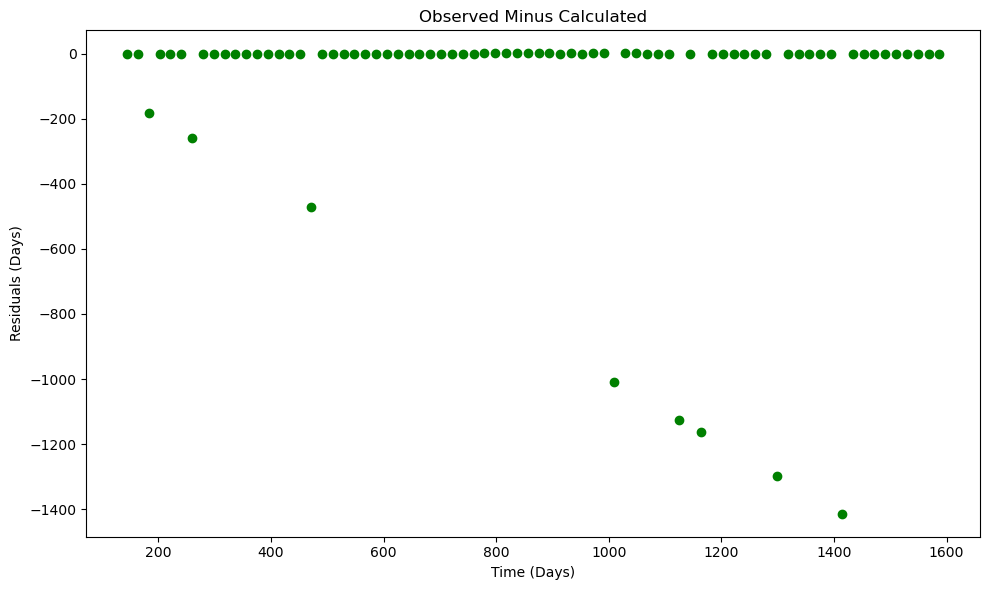

In [14]:
## NEW VALUES FOR 76 POINT MODEL
idx_transit_obs = np.array([
    618.5, 1552.5, 0., 3079.5, 4010., 4874., 0., 6601., 7450.5,
    8387., 9219., 10012.5, 10946., 11837., 12574., 13510.5, 14382., 0.,
    16188., 17090.5, 18025., 18895.5, 19789.5, 20728., 21618.5, 22555.5, 23448.,
    24345., 25281.5, 26174., 26946., 27250., 28184., 28987.5, 29915.5, 30550.5,
    31482., 32382.5, 33287., 34176.5, 35050., 35995., 36882.5, 37781., 38721.,
    0., 40544.5, 41412., 42302., 43110., 43980., 0., 45655., 0.,
    47218.5, 48139., 49031., 49958., 50844., 51692., 0., 53232., 54124.5,
    55057., 55884.5, 56815., 0., 58432.5, 59320.5, 60208.5, 60589., 61510.5,
    62387., 63316., 64181.5, 64861.5
])

t_transit_obs = np.array([
    144.23345025, 163.48253773, 0., 201.9595293, 221.19760321,
    240.42518217, 0., 278.92054228, 298.15782481, 317.43598403,
    336.67340021, 355.94167905, 375.20003123, 394.46892509, 413.71770399,
    433.00762213, 452.27730587, 0., 490.83733866, 510.11728734,
    529.39707865, 548.67662978, 567.94571849, 587.24517153, 606.52388644,
    625.81258656, 645.07044133, 664.358829, 683.63698336, 702.95609351,
    719.3841257, 741.45191912, 760.72072765, 779.97962545, 799.24904448,
    818.49823627, 837.75779496, 856.99696004, 876.25650749, 895.49548516,
    914.38684892, 933.9625334, 953.07817476, 972.43873284, 991.80924032,
    0., 1030.5394278, 1049.32719439, 1068.55431606, 1087.78157145,
    1107.00909015, 0., 1145.46507538, 0., 1183.87111732,
    1203.11020418, 1222.31871363, 1241.54763842, 1260.75602218, 1279.98463048,
    0., 1318.40029481, 1337.63835599, 1356.87614263, 1376.0727972,
    1395.29995833, 0., 1433.77454004, 1452.96088413, 1472.18829041,
    1491.40578109, 1510.63381462, 1529.882597, 1549.11121636, 1568.3093561,
    1587.52805759
])

t_transit_the = np.array([
    144.23345025, 163.47345025, 182.71345025, 201.95345025, 221.19345025,
    240.43345025, 259.67345025, 278.91345025, 298.15345025, 317.39345025,
    336.63345025, 355.87345025, 375.11345025, 394.35345025, 413.59345025,
    432.83345025, 452.07345025, 471.31345025, 490.55345025, 509.79345025,
    529.03345025, 548.27345025, 567.51345025, 586.75345025, 605.99345025,
    625.23345025, 644.47345025, 663.71345025, 682.95345025, 702.19345025,
    721.43345025, 740.67345025, 759.91345025, 779.15345025, 798.39345025,
    817.63345025, 836.87345025, 856.11345025, 875.35345025, 894.59345025,
    913.83345025, 933.07345025, 952.31345025, 971.55345025, 990.79345025,
    1010.03345025, 1029.27345025, 1048.51345025, 1067.75345025, 1086.99345025,
    1106.23345025, 1125.47345025, 1144.71345025, 1163.95345025, 1183.19345025,
    1202.43345025, 1221.67345025, 1240.91345025, 1260.15345025, 1279.39345025,
    1298.63345025, 1317.87345025, 1337.11345025, 1356.35345025, 1375.59345025,
    1394.83345025, 1414.07345025, 1433.31345025, 1452.55345025, 1471.79345025,
    1491.03345025, 1510.27345025, 1529.51345025, 1548.75345025, 1567.99345025,
    1587.23345025
])

idx_transit_dur_obs = np.array([
    7., 9., 0., 9., 8., 8., 0., 8., 7., 6., 4., 7., 8., 8., 6., 5., 8., 0.,
    8., 9., 6., 7., 7., 8., 7., 7., 6., 8., 7., 2., 6., 8., 6., 7., 7., 9.,
    6., 7., 8., 7., 42., 6., 21., 6., 22., 0., 45., 8., 8., 8., 8., 0., 2., 0.,
    7., 8., 8., 8., 8., 8., 0., 6., 7., 6., 7., 8., 0., 3., 7., 7., 8., 7.,
    6., 2., 7., 5.
])

t_transit_dur_obs = np.array([
    0.14304069, 0.18390757, 0., 0.18390219, 0.16346615, 0.1634641,
    0., 0.16346089, 0.14302815, 0.12259589, 0.10216405, 0.14303173,
    0.16346759, 0.16347027, 0.12260461, 0.12260614, 0.16347628, 0.,
    0.16347651, 0.18390982, 0.12260532, 0.14303761, 0.14303564, 0.16346695,
    0.14303138, 0.14302978, 0.12259613, 0.16346066, 0.14302844, 0.04086554,
    0.12259788, 0.16346673, 0.12260213, 0.14303822, 0.14304005, 0.18391036,
    0.12260747, 0.1430421, 0.16347586, 0.14303992, 0.8582301, 0.12260254,
    0.42910272, 0.12259893, 0.44952379, 0., 1.00119729, 0.16346076,
    0.16346177, 0.16346342, 0.16346582, 0., 0.04086772, 0.,
    0.14304109, 0.16347655, 0.16347668, 0.16347613, 0.1634749, 0.1634731,
    0., 0.12260148, 0.14303273, 0.12259802, 0.14302935, 0.1838936,
    0., 0.06129796, 0.14302975, 0.14303186, 0.16346761, 0.16347037,
    0.12260461, 0.04086881, 0.14304174, 0.12260761
])

print(np.size(idx_transit_obs));
print(np.size(t_transit_obs));
print(np.size(t_transit_the));
print(np.size(idx_transit_dur_obs));
print(np.size(t_transit_dur_obs));

omc = t_transit_obs - t_transit_the
print(omc)

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the, omc, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

[ 0.          0.00908748  0.00607905  0.00415296 -0.00826808  0.00709203
  0.00437456  0.04253378  0.03994996  0.0682288   0.08658098  0.11547484
  0.12425374  0.17417188  0.20385562  0.28388841  0.32383709  0.3636284
  0.40317953  0.43226824  0.49172128  0.53043619  0.57913631  0.59699108
  0.64537875  0.68353311  0.76264326  0.77846887  0.8072774   0.8261752
  0.85559423  0.86478602  0.88434471  0.88350979  0.90305724  0.90203491
  0.55339867  0.88908315  0.76472451  0.88528259  1.01579007  1.26597755
  0.81374414  0.80086581  0.7881212   0.7756399   0.75162513  0.67766707
  0.67675393  0.64526338  0.63418817  0.60257193  0.59118023  0.52684456
  0.52490574  0.52269238  0.47934695  0.46650808  0.46108979  0.40743388
  0.39484016  0.37233084  0.36036437  0.36914675  0.35776611  0.31590585
  0.29460734]
67


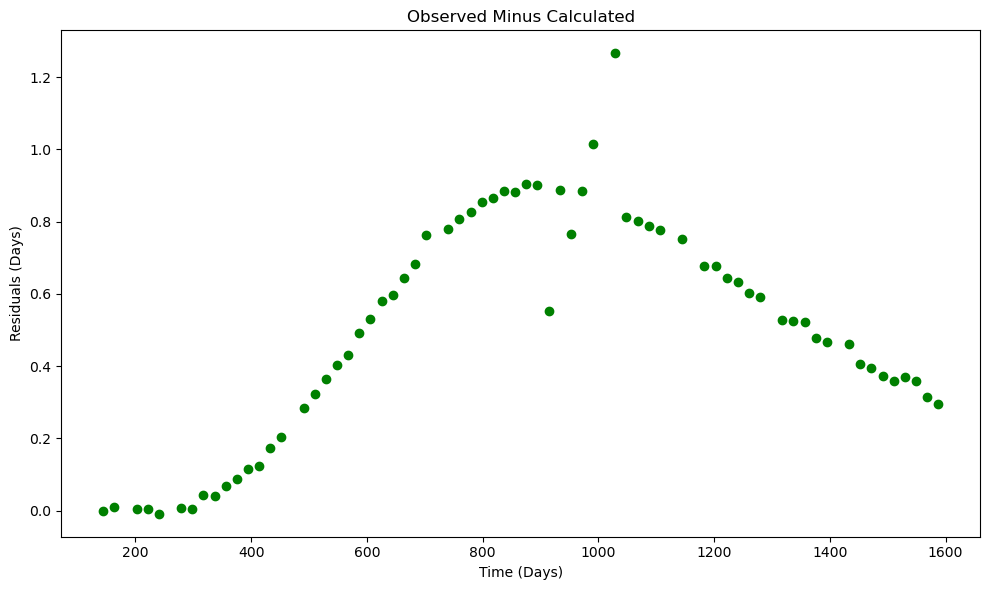

In [15]:
omc_nn = np.concatenate((omc[0:2], omc[3:6], omc[7:17], omc[18:30], omc[31:45], omc[46:51], omc[52:53], omc[54:60], omc[61:66], omc[67:76]));
t_transit_the_nn = np.concatenate((t_transit_the[0:2], t_transit_the[3:6], t_transit_the[7:17], t_transit_the[18:30], t_transit_the[31:45]
                                  , t_transit_the[46:51], t_transit_the[52:53], t_transit_the[54:60], t_transit_the[61:66], t_transit_the[67:76])); # no nan.
print(omc_nn)
print(np.size(omc_nn))

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the_nn, omc_nn, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

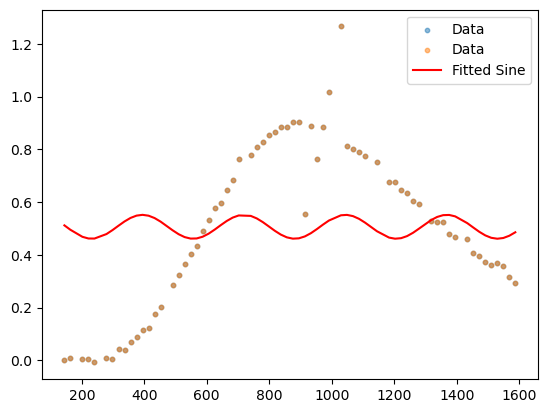

In [73]:
from scipy.optimize import curve_fit

# 1. Define the sine function to fit
def sine_model(x, amp, freq, phase, offset):
    return amp * np.sin(freq * x + phase) + offset

params, covariance = curve_fit(sine_model, t_transit_the_nn, omc_nn)

# Plotting the results
plt.scatter(t_transit_the_nn, omc_nn, label='Data', s=10, alpha=0.5)
plt.plot(t_transit_the_nn, sine_model(t_transit_the_nn, *params), color='red', label='Fitted Sine')
plt.legend()
plt.show()

# Google Gemini gave ideas for curve_fit to fit the graph into a sine wave. It sucks. Naturally, we are resigned to fit it by eye.

In [17]:
# By eye curve fit
# Peak of ~0.902, 0.903 from data (ignoring weird outlier thingy) so amplitude ~0.451 days.
# ... This is because, at the start, it 'seems' like we are at the very bottom - may be untrue.
# Check data without nans and see when 0.451 is reached (find it while slope is ascending and descending).
# ... This finds half the timescale. Justification: This is half the time for upwards, half the time for downwards.
# Ascending: between 22 and 23.
# Descending: between 67 and 68.

amplitude = 0.451
timescale = np.mean(t_transit_the[67:69]) - np.mean(t_transit_the[22:24]); # Approximately the subtracted means? I could fit a line for 
#... to find the interpolated time at which 0.451 is reached, but i think uncertainty factor is already large here.
print(amplitude)
print(timescale)

0.451
865.8000000000001


In [29]:
pip install ttvfast

Note: you may need to restart the kernel to use updated packages.


In [30]:
# TTVFast Program to model behaviour
# Code Reference: Deck, Agol, Holman, & Nesvorny (2014), ApJ, 787, 132, arXiv:1403.1895.

from ttvfast import models 

gravity = 0.000295994511                        # AU^3/day^2/M_sun
stellar_mass = 0.95573417954                    # M_sun


planet1 = models.Planet(
    mass=0.00002878248,                         # M_sun
    period=1.0917340278625494e+01,              # days
    eccentricity=5.6159310042858110e-02,
    inclination=9.0921164935951211e+01,         # degrees
    longnode=-1.1729336712101943e-18,           # degrees
    argument=1.8094838714599581e+02,            # degrees
    mean_anomaly=-8.7093652691581923e+01,       # degrees
)

planet2 = models.Planet(
    mass=0.00061895914,
    period=2.2266898036209028e+01,
    eccentricity=5.6691301931178648e-02,
    inclination=8.7598285693573246e+01,
    longnode=4.6220554014026838e-01,
    argument=1.6437004273382669e+00,
    mean_anomaly=-1.9584857031843157e+01,
)

planets = [planet1, planet2]
Time = -1045                                    # days
dt = 0.54                                       # days
Total = 1700                                    # days

results = ttvfast.ttvfast(planets, stellar_mass, Time, dt, Total)

NameError: name 'ttvfast' is not defined

In [47]:
mlem

# Limitations (see Overleaf):
# - 'small' amount of data, even though 4 years we don't even get a full period of analysis!
# - Not really sinusoidal. Tough to get timescale of deviation otherwise.
# - problems with taking middle of double peaks [40, 42, 44, 46]
# - No consideration of trend of flux (no star spot model, for example), used normalise and flatten and don't know the limitations of those.
# - No peak around some expected peaks because of loss of data in-between light curves that were stitched together.
# - Some problems with peaks (see above) may cause problems with data.

NameError: name 'mlem' is not defined

[ 0.00000000e+00  9.08748000e-03 -1.82713450e+02  6.07905000e-03
  4.15296000e-03 -8.26808000e-03 -2.59673450e+02  7.09203000e-03
  4.37456000e-03  4.25337800e-02  3.99499600e-02  6.82288000e-02
  8.65809800e-02  1.15474840e-01  1.24253740e-01  1.74171880e-01
  2.03855620e-01 -4.71313450e+02  2.83888410e-01  3.23837090e-01
  3.63628400e-01  4.03179530e-01  4.32268240e-01  4.91721280e-01
  5.30436190e-01  5.79136310e-01  5.96991080e-01  6.45378750e-01
  6.83533110e-01  7.62643260e-01 -2.04932455e+00  7.78468870e-01
  8.07277400e-01  8.26175200e-01  8.55594230e-01  8.64786020e-01
  8.84344710e-01  8.83509790e-01  9.03057240e-01  9.02034910e-01
  5.53398670e-01  8.89083150e-01  7.64724510e-01  8.85282590e-01
  1.01579007e+00 -1.01003345e+03  1.26597755e+00  8.13744140e-01
  8.00865810e-01  7.88121200e-01  7.75639900e-01 -1.12547345e+03
  7.51625130e-01 -1.16395345e+03  6.77667070e-01  6.76753930e-01
  6.45263380e-01  6.34188170e-01  6.02571930e-01  5.91180230e-01
 -1.29863345e+03  5.26844

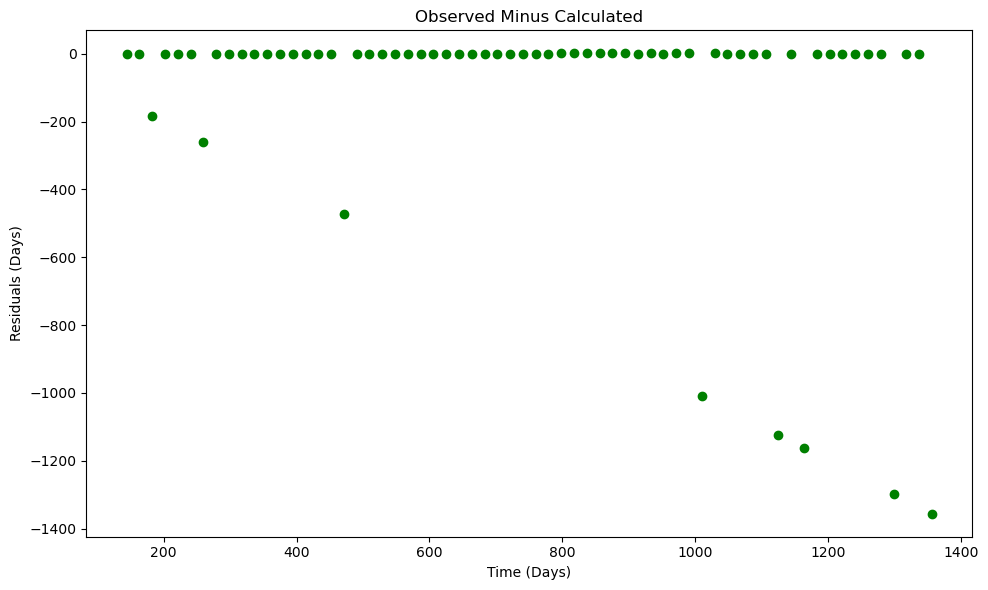

In [29]:
## NEW VALUES FOR 64 POINT MODEL
idx_transit_obs = np.array([618.5, 1552.5, 0, 3079.5, 4010, 4874, 0, 6601, 7450.5,
  8387, 9219, 10012.5, 10946, 11837, 12574, 13510.5, 14382, 0,
 16188, 17090.5, 18025, 18895.5, 19789.5, 20728, 21618.5, 22555.5, 23448,
 24345, 25281.5, 26174, 26946,  27250,  28184,  28987.5, 29915.5, 30550.5,
 31482,  32382.5, 33287,  34176.5, 35050,  35995,  36882.5, 37781,  38721,
 0,     40544.5,   41412,   42302,  43110,  43980,     0,  45655,    0,
 47218.5, 48139,   49031,    49958, 50844, 51692,     0,  53232,  54124.5,
 0])

t_transit_obs = np.array([144.23345025, 163.48253773, 0, 201.9595293, 221.19760321,
 240.42518217, 0, 278.92054228, 298.15782481, 317.43598403,
 336.67340021, 355.94167905, 375.20003123, 394.46892509, 413.71770399,
 433.00762213, 452.27730587, 0, 490.83733866, 510.11728734,
 529.39707865, 548.67662978, 567.94571849, 587.24517153, 606.52388644,
 625.81258656, 645.07044133, 664.358829, 683.63698336, 702.95609351,
 719.3841257,  741.45191912, 760.72072765, 779.97962545, 799.24904448,
 818.49823627, 837.75779496, 856.99696004, 876.25650749, 895.49548516,
 914.38684892, 933.9625334,  953.07817476, 972.43873284, 991.80924032,
    0,     1030.5394278,  1049.32719439, 1068.55431606, 1087.78157145,
 1107.00909015,    0,       1145.46507538,    0,         1183.87111732,
 1203.11020418, 1222.31871363, 1241.54763842, 1260.75602218, 1279.98463048,
    0,         1318.40029481, 1337.63835599,    0])

idx_transit_dur_obs = np.array([7, 9, 0, 9, 8, 8, 0, 8, 7, 6, 4, 7, 8, 8, 6, 5, 8, 0, 8, 9, 6, 7, 7, 8,
 7, 7, 6, 8, 7, 2, 6,  8,  6,  7,  7,  9, 6,  7,  8,  7, 42,  6, 21,  6, 22, 0, 45,  8,  8,  8,  8,  0,  2,  0,
  7,  8,  8,  8,  8,  8,  0,  6,  7,  0])

t_transit_dur_obs = np.array([0.14304069, 0.18390757, 0, 0.18390219, 0.16346615, 0.1634641,
 0, 0.16346089, 0.14302815, 0.12259589, 0.10216405, 0.14303173,
 0.16346759, 0.16347027, 0.12260461, 0.12260614, 0.16347628, 0,
 0.16347651, 0.18390982, 0.12260532, 0.14303761, 0.14303564, 0.16346695,
 0.14303138, 0.14302978, 0.12259613, 0.16346066, 0.14302844, 0.04086554,
 0.12259788, 0.16346673, 0.12260213, 0.14303822, 0.14304005, 0.18391036,
 0.12260747, 0.1430421,  0.16347586, 0.14303992, 0.8582301,  0.12260254,
 0.42910272, 0.12259893, 0.44952379, 0,         1.00119729, 0.16346076,
 0.16346177, 0.16346342, 0.16346582, 0,         0.04086772, 0,
 0.14304109, 0.16347655, 0.16347668, 0.16347613, 0.1634749,  0.1634731,
 0,         0.12260148, 0.14303273, 0])
# -----
t_transit_the = np.array([
    144.23345025, 163.47345025, 182.71345025, 201.95345025, 221.19345025,
    240.43345025, 259.67345025, 278.91345025, 298.15345025, 317.39345025,
    336.63345025, 355.87345025, 375.11345025, 394.35345025, 413.59345025,
    432.83345025, 452.07345025, 471.31345025, 490.55345025, 509.79345025,
    529.03345025, 548.27345025, 567.51345025, 586.75345025, 605.99345025,
    625.23345025, 644.47345025, 663.71345025, 682.95345025, 702.19345025,
    721.43345025, 740.67345025, 759.91345025, 779.15345025, 798.39345025,
    817.63345025, 836.87345025, 856.11345025, 875.35345025, 894.59345025,
    913.83345025, 933.07345025, 952.31345025, 971.55345025, 990.79345025,
    1010.03345025, 1029.27345025, 1048.51345025, 1067.75345025, 1086.99345025,
    1106.23345025, 1125.47345025, 1144.71345025, 1163.95345025, 1183.19345025,
    1202.43345025, 1221.67345025, 1240.91345025, 1260.15345025, 1279.39345025,
    1298.63345025, 1317.87345025, 1337.11345025, 1356.35345025
])

omc = t_transit_obs - t_transit_the
print(omc)

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the, omc, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

[ 0.          0.00908748  0.00607905  0.00415296 -0.00826808  0.00709203
  0.00437456  0.04253378  0.03994996  0.0682288   0.08658098  0.11547484
  0.12425374  0.17417188  0.20385562  0.28388841  0.32383709  0.3636284
  0.40317953  0.43226824  0.49172128  0.53043619  0.57913631  0.59699108
  0.64537875  0.68353311  0.76264326  0.77846887  0.8072774   0.8261752
  0.85559423  0.86478602  0.88434471  0.88350979  0.90305724  0.90203491
  0.55339867  0.88908315  0.76472451  0.88528259  1.01579007  1.26597755
  0.81374414  0.80086581  0.7881212   0.7756399   0.75162513  0.67766707
  0.67675393  0.64526338  0.63418817  0.60257193  0.59118023  0.52684456
  0.52490574]
55


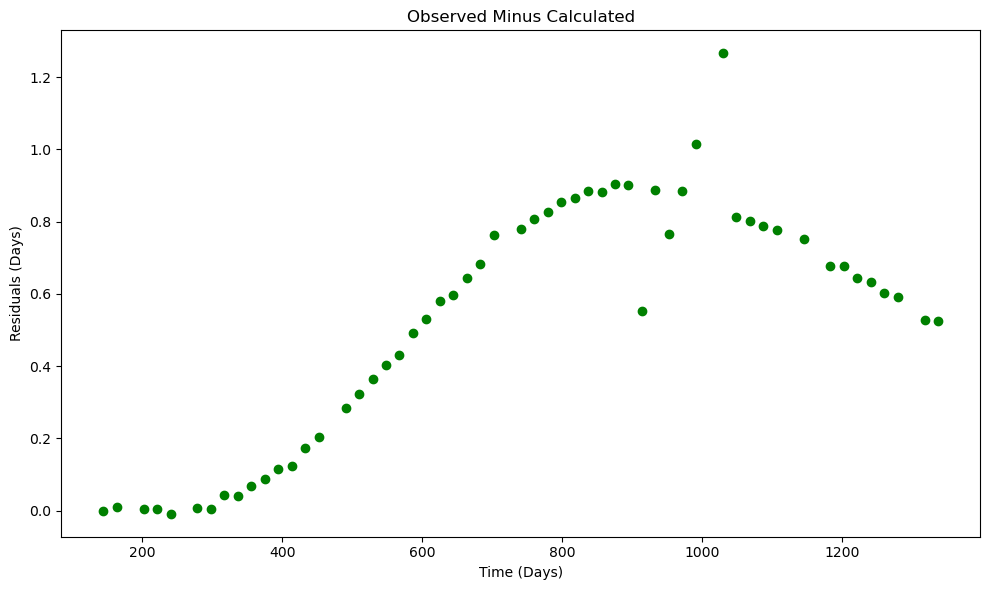

In [18]:
omc_nn = np.concatenate((omc[0:2], omc[3:6], omc[7:17], omc[18:30], omc[31:45], omc[46:51], omc[52:53], omc[54:60], omc[61:63]));
t_transit_the_nn = np.concatenate((t_transit_the[0:2], t_transit_the[3:6], t_transit_the[7:17], t_transit_the[18:30], t_transit_the[31:45]
                                  , t_transit_the[46:51], t_transit_the[52:53], t_transit_the[54:60], t_transit_the[61:63])); # no nan.
print(omc_nn)
print(np.size(omc_nn))

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the_nn, omc_nn, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

In [99]:
## NEW VALUES FOR 45 POINT MODEL
#idx_transit_obs = [618.5, 1552.5, 0, 3079.5, 4010, 4874, 0, 6601, 7450.5,
  8387, 9219, 10012.5, 10946, 11837, 12574, 13510.5, 14382, 0,
 16188, 17090.5, 18025, 18895.5, 19789.5, 20728, 21618.5, 22555.5, 23448,
 24345, 25281.5, 26174, 26946,  27250,  28184,  28987.5, 29915.5, 30550.5,
 31482,  32382.5, 33287,  34176.5, 35050,  35995,  36882.5, 37781,  38721]

t_transit_obs = [144.23345025, 163.48253773, 0, 201.9595293, 221.19760321,
 240.42518217, 0, 278.92054228, 298.15782481, 317.43598403,
 336.67340021, 355.94167905, 375.20003123, 394.46892509, 413.71770399,
 433.00762213, 452.27730587, 0, 490.83733866, 510.11728734,
 529.39707865, 548.67662978, 567.94571849, 587.24517153, 606.52388644,
 625.81258656, 645.07044133, 664.358829, 683.63698336, 702.95609351,
 719.3841257,  741.45191912, 760.72072765, 779.97962545, 799.24904448,
 818.49823627, 837.75779496, 856.99696004, 876.25650749, 895.49548516,
 914.38684892, 933.9625334,  953.07817476, 972.43873284, 991.80924032]

idx_transit_dur_obs = [7, 9, 0, 9, 8, 8, 0, 8, 7, 6, 4, 7, 8, 8, 6, 5, 8, 0, 8, 9, 6, 7, 7, 8,
 7, 7, 6, 8, 7, 2, 6,  8,  6,  7,  7,  9, 6,  7,  8,  7, 42,  6, 21,  6, 22]

t_transit_dur_obs = [0.14304069, 0.18390757, 0, 0.18390219, 0.16346615, 0.1634641,
 0, 0.16346089, 0.14302815, 0.12259589, 0.10216405, 0.14303173,
 0.16346759, 0.16347027, 0.12260461, 0.12260614, 0.16347628, 0,
 0.16347651, 0.18390982, 0.12260532, 0.14303761, 0.14303564, 0.16346695,
 0.14303138, 0.14302978, 0.12259613, 0.16346066, 0.14302844, 0.04086554,
 0.12259788, 0.16346673, 0.12260213, 0.14303822, 0.14304005, 0.18391036,
 0.12260747, 0.1430421,  0.16347586, 0.14303992, 0.8582301,  0.12260254,
 0.42910272, 0.12259893, 0.44952379]
t_transit_the: [144.23345025, 163.47345025, 182.71345025, 201.95345025, 221.19345025,
 240.43345025, 259.67345025, 278.91345025, 298.15345025, 317.39345025,
 336.63345025, 355.87345025, 375.11345025, 394.35345025, 413.59345025,
 432.83345025, 452.07345025, 471.31345025, 490.55345025, 509.79345025,
 529.03345025, 548.27345025, 567.51345025, 586.75345025, 605.99345025,
 625.23345025, 644.47345025, 663.71345025, 682.95345025, 702.19345025,
 721.43345025, 740.67345025, 759.91345025, 779.15345025, 798.39345025,
 817.63345025, 836.87345025, 856.11345025, 875.35345025, 894.59345025,
 913.83345025, 933.07345025, 952.31345025, 971.55345025, 990.79345025]

omc = t_transit_obs - t_transit_the
print(omc)

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the, omc, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (45,) (64,) 

[ 0.          0.00908748  0.00607905  0.00415296 -0.00826808  0.00709203
  0.00437456  0.04253378  0.03994996  0.0682288   0.08658098  0.11547484
  0.12425374  0.17417188  0.20385562  0.28388841  0.32383709  0.3636284
  0.40317953  0.43226824  0.49172128  0.53043619  0.57913631  0.59699108
  0.64537875  0.68353311  0.76264326  0.77846887  0.8072774   0.8261752
  0.85559423  0.86478602  0.88434471  0.88350979  0.90305724  0.90203491
  0.55339867  0.88908315  0.76472451  0.88528259  1.01579007]
41


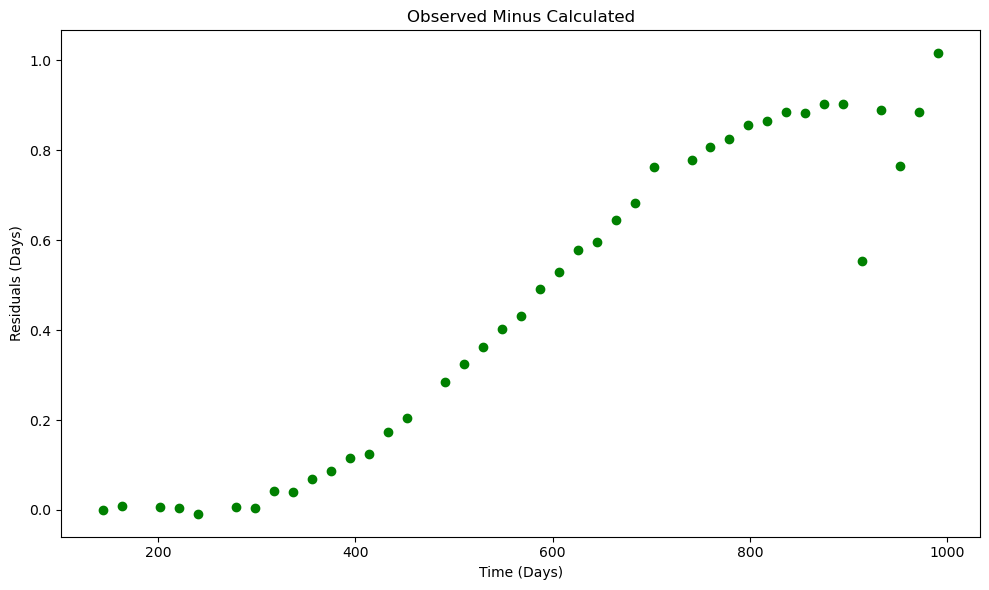

In [56]:
#omc_nn = np.concatenate((omc[0:2], omc[3:6], omc[7:17], omc[18:30], omc[31:45]));
#t_transit_the_nn = np.concatenate((t_transit_the[0:2], t_transit_the[3:6], t_transit_the[7:17], t_transit_the[18:30], t_transit_the[31:45])); # no nan.
#print(omc_nn)
#print(np.size(omc_nn))

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the_nn, omc_nn, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

[ 0.          0.00908748         nan  0.00607905  0.00415296 -0.00826808
         nan  0.00709203  0.00437456  0.04253378  0.03994996  0.0682288
  0.08658098  0.11547484  0.12425374  0.17417188  0.20385562         nan
  0.28388841  0.32383709  0.3636284   0.40317953  0.43226824  0.49172128
  0.53043619  0.57913631  0.59699108  0.64537875  0.68353311  0.76264326
  0.        ]


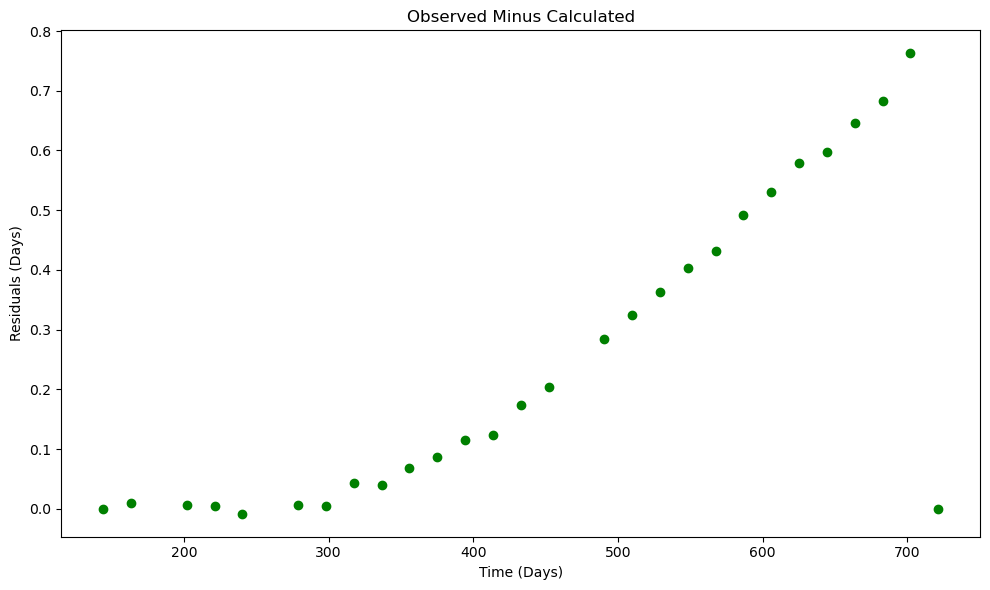

In [45]:
## OLD: 31 point model, when it seemed only half a period was obtained (a suspiciously long period at that)
# this was the data
#idx_transit_obs_old = [618.5, 1552.5, 0, 3079.5, 4010, 4874, 0, 6601, 7450.5,
#  8387, 9219, 10012.5, 10946, 11837, 12574, 13510.5, 14382, 0,
# 16188, 17090.5, 18025, 18895.5, 19789.5, 20728, 21618.5, 22555.5, 23448,
# 24345, 25281.5, 26174, 26946]
#
# t_transit_obs_old = [144.23345025, 163.48253773, 0, 201.9595293, 221.19760321,
 240.42518217, 0, 278.92054228, 298.15782481, 317.43598403,
 336.67340021, 355.94167905, 375.20003123, 394.46892509, 413.71770399,
 433.00762213, 452.27730587, 0, 490.83733866, 510.11728734,
 529.39707865, 548.67662978, 567.94571849, 587.24517153, 606.52388644,
 625.81258656, 645.07044133, 664.358829, 683.63698336, 702.95609351,
 721.43345025]

idx_transit_dur_obs_old = [7, 9, 0, 9, 8, 8, 0, 8, 7, 6, 4, 7, 8, 8, 6, 5, 8, 0, 8, 9, 6, 7, 7, 8,
 7, 7, 6, 8, 7, 2]

t_transit_dur_obs_old = [0.14304069, 0.18390757, 0, 0.18390219, 0.16346615, 0.1634641,
 0, 0.16346089, 0.14302815, 0.12259589, 0.10216405, 0.14303173,
 0.16346759, 0.16347027, 0.12260461, 0.12260614, 0.16347628, 0,
 0.16347651, 0.18390982, 0.12260532, 0.14303761, 0.14303564, 0.16346695,
 0.14303138, 0.14302978, 0.12259613, 0.16346066, 0.14302844, 0.04086554,
 0.12259788]

nan_indices = [2, 6, 17]
for idx in nan_indices:
    t_transit_obs_old[idx] = np.nan

omc = t_transit_obs_old - t_transit_the[0:np.size(t_transit_obs_old)]
print(omc)

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the[0:np.size(omc)], omc, color = 'green');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()

[ 0.          0.00908748  0.00607905  0.00415296 -0.00826808  0.00709203
  0.00437456  0.04253378  0.03994996  0.0682288   0.08658098  0.11547484
  0.12425374  0.17417188  0.20385562  0.28388841  0.32383709  0.3636284
  0.40317953  0.43226824  0.49172128  0.53043619  0.57913631  0.59699108
  0.64537875  0.68353311  0.76264326]
27
[ 0.00143193 -0.36658318]


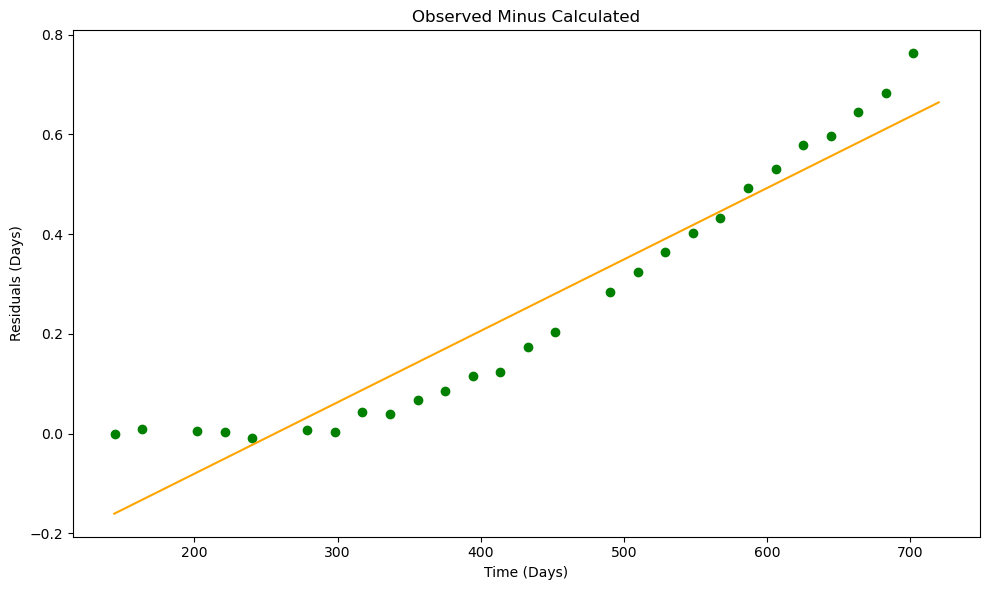

In [80]:
# Rough errors in the theoretical value of Kepler's average period 
# ... will result in a linear long-term trend from 0. To resolve
# ... this, we will fit a line and subtract it.

omc[30] = np.nan # remove outlier

# polyfit cannot deal with nans. 2, 6, 17, 30
# omc3, t_transit_the_3 have nans removed.
omc2 = np.concatenate((omc[0:2], omc[3:6], omc[7:17], omc[18:30]));
t_transit_the_nn = np.concatenate((t_transit_the[0:2], t_transit_the[3:6], t_transit_the[7:17], t_transit_the[18:30])); # no nan.
print(omc2)
print(np.size(omc2))


trend_poly = np.polyfit(t_transit_the_nn, omc2, 1);
print(trend_poly)

trend_x = np.arange(144, 721);
trend_y = np.zeros(np.size(trend_x));
for idx in range(np.size(trend_x)):
    trend_y[idx] = trend_poly[0] * trend_x[idx] + trend_poly[1];

plt.figure(figsize = (10, 6))
plt.scatter(t_transit_the_nn, omc2, color = 'green');
plt.plot(trend_x, trend_y, color = 'orange');
plt.xlabel('Time (Days)')
plt.ylabel('Residuals (Days)')
plt.title('Observed Minus Calculated');

plt.tight_layout()
plt.show()